### SIT742 - Modern Data Science
### Joshua Bevan
### s224586613

This notebook has been written to satisfy the requirements for Assignment 2 of SIT742. Part 1 will be focusing on data manipulation and pyspark. Part 2 will focus on advanced data science techniques for a particular scenario.

In [6]:
import sys, subprocess, importlib, os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from collections import Counter
import re
from wordcloud import WordCloud
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
import itertools
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import warnings
import camelot, tabula, pandas as pd, re

from pyspark.sql import SparkSession, functions as F, types as types
spark = SparkSession.builder.appName("SIT742-A2").config("spark.ui.showConsoleProgress","false").getOrCreate()

BASE = "/home/josh/code/SIT742 - Modern Data Science/Assignment 2/business_review_submission"
REVIEWS_PATH = f"{BASE}/review.csv"
META_PATH    = f"{BASE}/meta-review-business.csv"


Q1.1

In [7]:
reviews_sdf = spark.read.csv(REVIEWS_PATH, header=True, inferSchema=True, escape='"', multiLine=True)
for c in reviews_sdf.columns: reviews_sdf = reviews_sdf.withColumnRenamed(c, c.strip().lower())

col_text   = "text" if "text" in reviews_sdf.columns else "review_text"
col_time   = "time" if "time" in reviews_sdf.columns else "review_time"
col_gmap   = "gmap_id"
col_user   = "userid" if "userid" in reviews_sdf.columns else ("user_id" if "user_id" in reviews_sdf.columns else "user")
col_rating = "rating" if "rating" in reviews_sdf.columns else "stars"

# Clean up the data by filtering out rows with invalid data
reviews_sdf = reviews_sdf.filter(F.col(col_user).isNotNull() & F.col(col_time).isNotNull())

reviews_sdf = reviews_sdf.withColumn(
    col_text,
    F.when(F.col(col_text).isNull() | (F.lower(F.col(col_text)) == F.lit("none")) | (F.length(F.trim(F.col(col_text))) == 0), F.lit("no review")).otherwise(F.col(col_text))
)

# Handle timestamps - assume they are unix timestamps in milliseconds
time_as_double = F.col(col_time).cast("double")
# Convert milliseconds to timestamp
timestamp_parsed = F.to_timestamp(F.from_unixtime(time_as_double / 1000))

# Add the timestamp and date columns
reviews_sdf = reviews_sdf.withColumn("timestamp_parsed", timestamp_parsed).withColumn("newtime", F.to_date(timestamp_parsed))

reviews_sdf.select(col_user, col_gmap, col_time, "timestamp_parsed", "newtime", col_text).show(5, truncate=False)

+---------------------+-------------------------------------+-------------+-------------------+----------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|user_id              |gmap_id                              |time         |timestamp_parsed   |newtime   |text                                      

Q1.2

In [25]:
gmap_counts_sdf = reviews_sdf.groupBy(col_gmap).agg(F.count("*").cast("double").alias("review_count"))
gmap_counts_sdf.orderBy(F.desc("review_count")).show(5, truncate=False)

# Use the timestamp_parsed column we already created instead of trying to parse again
df = reviews_sdf.select(col_user, col_gmap, col_rating, col_text, "newtime", "timestamp_parsed").toPandas()
df["timestamp_parsed"] = pd.to_datetime(df["timestamp_parsed"])
df["newtime"] = pd.to_datetime(df["newtime"])
df["review_time"] = df["timestamp_parsed"].dt.hour.fillna(0).astype(int)
df.head()

+-------------------------------------+------------+
|gmap_id                              |review_count|
+-------------------------------------+------------+
|0x56c897b9ce6000df:0xd707e127588a8c6c|2833.0      |
|0x56c899d058920487:0x12882cc9133f2f54|2594.0      |
|0x56c897c63697ee39:0x419904ababbc740b|2258.0      |
|0x56c8965ee2fb87a1:0x559736347bd48842|2237.0      |
|0x56c89629bde7481f:0x7e8a9413ab25d5d |2219.0      |
+-------------------------------------+------------+
only showing top 5 rows



,user_id,gmap_id,rating,text,newtime,timestamp_parsed,review_time
0,1.091298e+20,0x56b646ed2220b77f:0xd8975e316de80952,5,We always stay here when in Valdez for silver ...,2019-08-21,2019-08-21 06:12:31,6
1,1.132409e+20,0x56b646ed2220b77f:0xd8975e316de80952,5,Great campground for the price. Nice hot unlim...,2017-09-09,2017-09-09 10:46:22,10
2,1.130448e+20,0x56b646ed2220b77f:0xd8975e316de80952,4,We tent camped here for 2 nights while explori...,2016-09-25,2016-09-25 11:11:41,11
3,1.103292e+20,0x56b646ed2220b77f:0xd8975e316de80952,4,"This place is just a few miles outside Valdez,...",2016-09-03,2016-09-03 09:22:15,9
4,1.089896e+20,0x56b646ed2220b77f:0xd8975e316de80952,5,Probably the nicest and cleanest campground we...,2018-06-22,2018-06-22 16:43:31,16


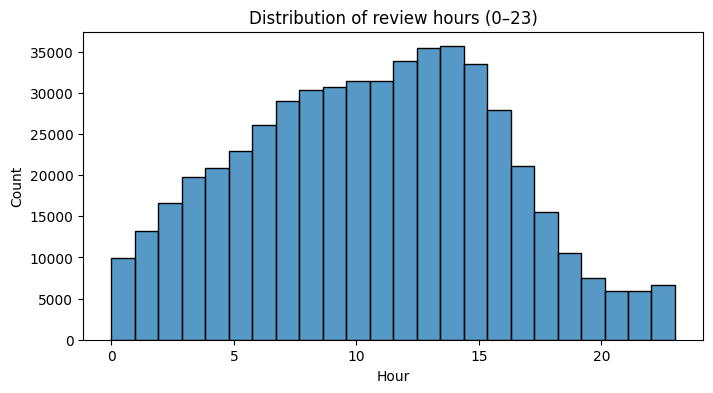

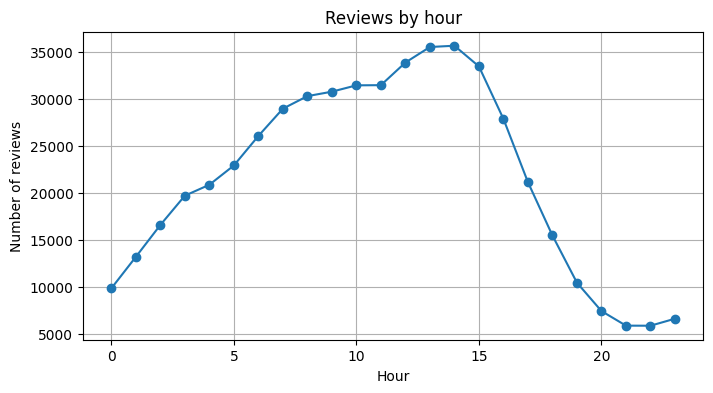

In [26]:
plt.figure(figsize=(8,4))
sns.histplot(df["review_time"], bins=24)
plt.title("Distribution of review hours (0–23)")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,4))
df.groupby("review_time").size().plot(kind="line", marker="o")
plt.title("Reviews by hour")
plt.xlabel("Hour")
plt.ylabel("Number of reviews")
plt.grid(True)
plt.show()


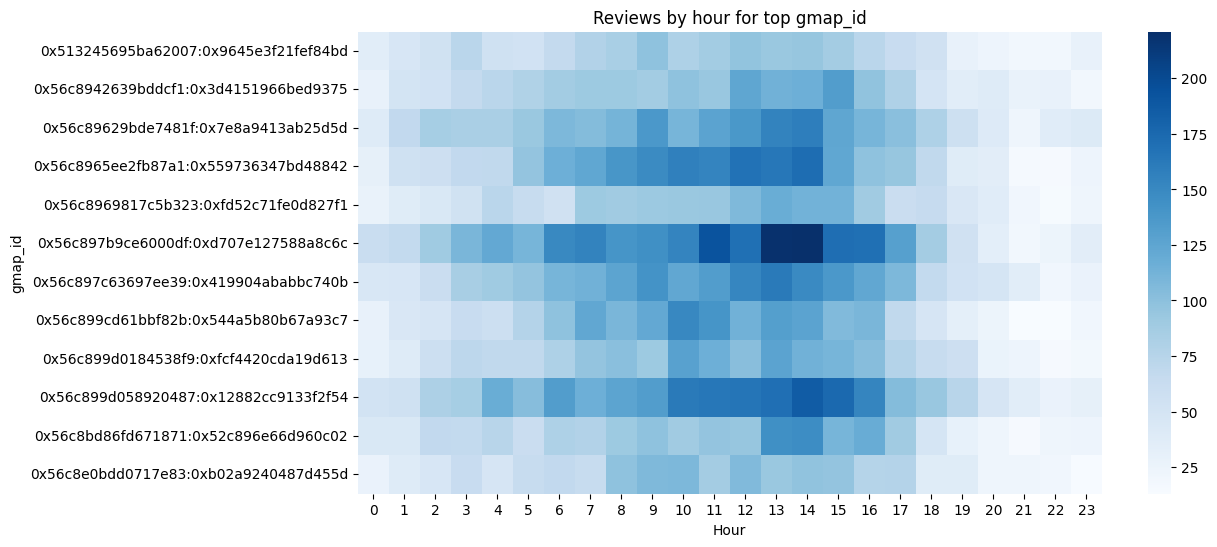

Businesses reviewed in morning: 6006 out of 6019


In [27]:
top_ids = df[col_gmap].value_counts().head(12).index
pvt = df[df[col_gmap].isin(top_ids)].pivot_table(index=col_gmap, columns="review_time", values=col_user, aggfunc="size", fill_value=0)
plt.figure(figsize=(12,6))
sns.heatmap(pvt, cmap="Blues")
plt.title("Reviews by hour for top gmap_id")
plt.xlabel("Hour")
plt.ylabel("gmap_id")
plt.show()

morning_unique = df[df["review_time"].between(6,11)][col_gmap].nunique()
total_unique = df[col_gmap].nunique()
print("Businesses reviewed in morning:", morning_unique, "out of", total_unique)


Q1.3

In [8]:
meta_sdf = spark.read.csv(META_PATH, header=True, inferSchema=True, escape='"', multiLine=True)
for c in meta_sdf.columns: meta_sdf = meta_sdf.withColumnRenamed(c, c.strip().lower())

# Rename columns in meta to avoid conflicts
meta_sdf = meta_sdf.withColumnRenamed("name", "business_name")
name_col = "business_name"
cat_col  = "category" if "category" in meta_sdf.columns else ("categories" if "categories" in meta_sdf.columns else "category")

joined_sdf = reviews_sdf.join(meta_sdf, on=col_gmap, how="left")

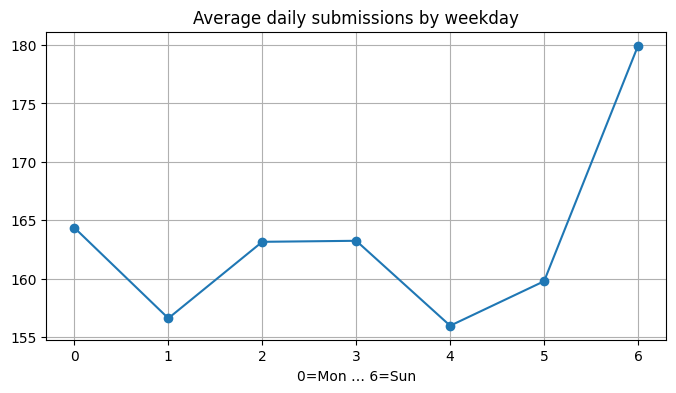

Top weekday: Sun


In [29]:
df_day = df.copy()
day_counts = df_day.groupby(df_day["newtime"].dt.date).size().rename("count").to_frame()
labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
day_counts["weekday_idx"] = pd.to_datetime(day_counts.index).weekday
avg_by_wd = day_counts.groupby("weekday_idx")["count"].mean()
plt.figure(figsize=(8,4))
avg_by_wd.plot(marker="o")
plt.title("Average daily submissions by weekday")
plt.xlabel("0=Mon … 6=Sun")
plt.grid(True)
plt.show()
top_weekday = labels[int(avg_by_wd.idxmax())]
print("Top weekday:", top_weekday)


In [30]:
wk = top_weekday
wk_df = joined_sdf.where(F.date_format(F.col("newtime"), "E") == wk)
agg_wk = wk_df.groupBy(name_col, cat_col).agg(F.avg(F.col(col_rating)).alias("avg_rating"), F.count("*").alias("n"))
top_wk = agg_wk.orderBy(F.desc("avg_rating"), F.desc("n")).limit(10).toPandas()
top_wk

,business_name,category,avg_rating,n
0,Escape Anchorage,"['Escape room center', 'Entertainer']",5.0,24
1,House of Green Recreational Marijuana Dispensa...,"['Cannabis store', 'Alternative medicine pract...",5.0,21
2,Anchorage Ace Hardware,"['Hardware store', 'Home improvement store', '...",5.0,16
3,Winner Creek Gorge Trail Head (Lower Winner Cr...,"['Hiking area', 'Tourist attraction']",5.0,14
4,Aurora Animal Clinic,['Animal hospital'],5.0,13
5,Far North Yarn Co.,['Yarn store'],5.0,13
6,Wedgewood Wildlife Sanctuary,"['Nature preserve', 'Bird watching area', 'Tou...",5.0,12
7,Stan Stephens Glacier & Wildlife Cruises,"['Cruise agency', 'Boat tour agency']",5.0,12
8,Lucky Raven Tobacco,['Tobacco shop'],5.0,12
9,Ramiro's,['Mexican restaurant'],5.0,11


Q1.4

In [31]:
nltk.download('stopwords', quiet=True)

stop = set(stopwords.words("english")) | {"no","review"}
df_text = reviews_sdf.select(col_text, "newtime").toPandas()
df_text["year"] = pd.to_datetime(df_text["newtime"]).dt.year

def tokenize(s):
    if not isinstance(s, str): return []
    s = re.sub(r"[^a-z0-9\s]"," ", s.lower())
    return [t for t in s.split() if t not in stop and len(t)>=3]

all_tokens = []
for t in df_text[col_text].tolist(): all_tokens.extend(tokenize(t))
Counter(all_tokens).most_common(30)

[('great', 83280),
 ('good', 64687),
 ('food', 63819),
 ('place', 48185),
 ('service', 46074),
 ('staff', 29021),
 ('friendly', 26633),
 ('nice', 26613),
 ('always', 23754),
 ('best', 22058),
 ('get', 20900),
 ('love', 20013),
 ('time', 19098),
 ('like', 17053),
 ('one', 15954),
 ('clean', 12740),
 ('people', 12709),
 ('really', 12668),
 ('amazing', 12597),
 ('prices', 12351),
 ('store', 12233),
 ('awesome', 12150),
 ('back', 12001),
 ('well', 11811),
 ('would', 11445),
 ('helpful', 10720),
 ('little', 10479),
 ('excellent', 10364),
 ('customer', 9537),
 ('got', 9513)]

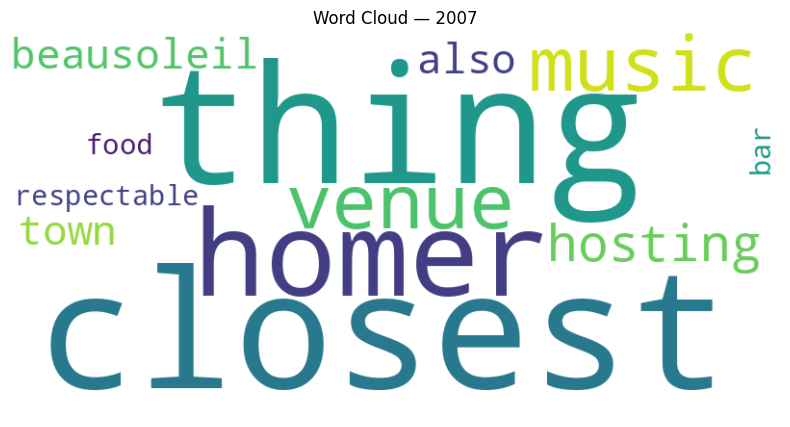

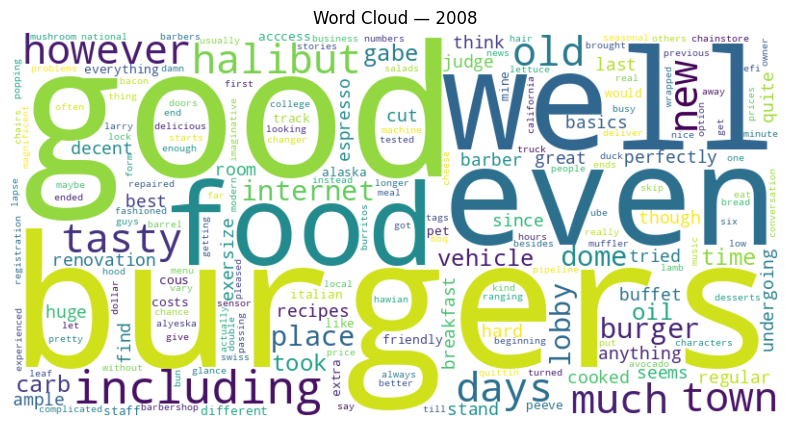

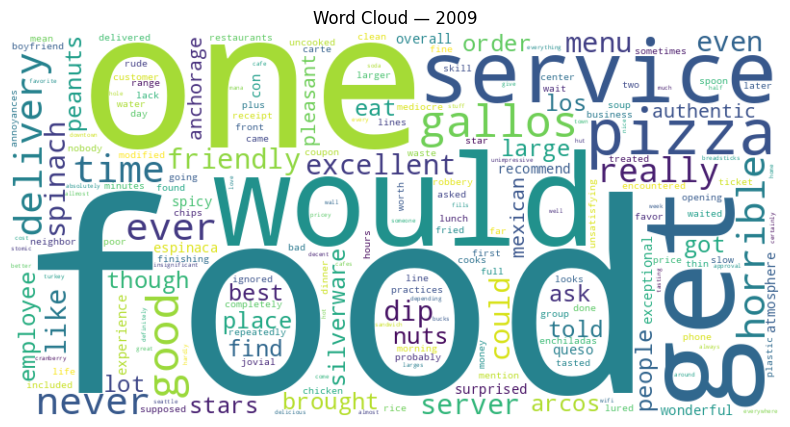

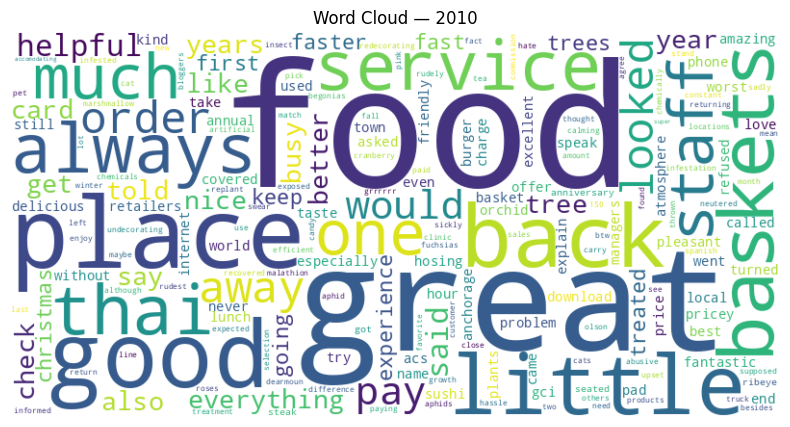

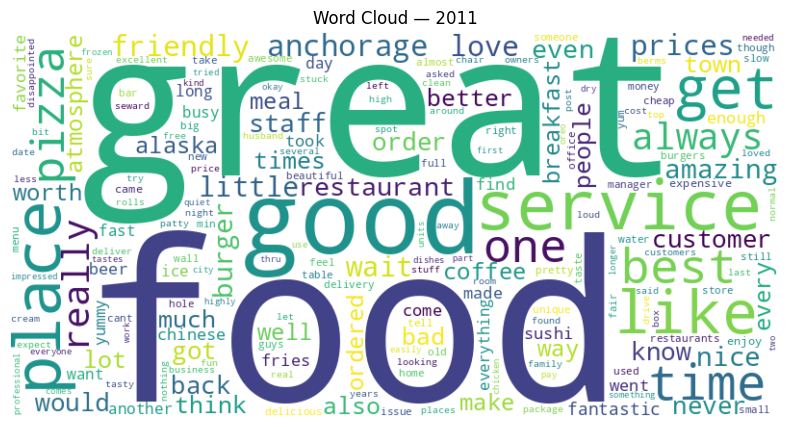

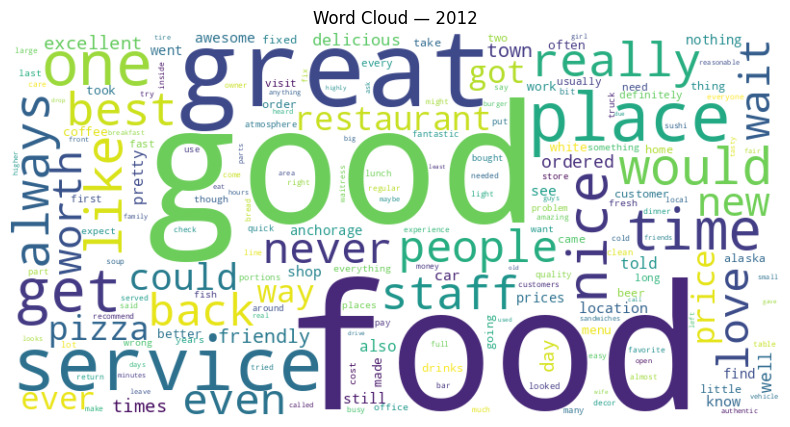

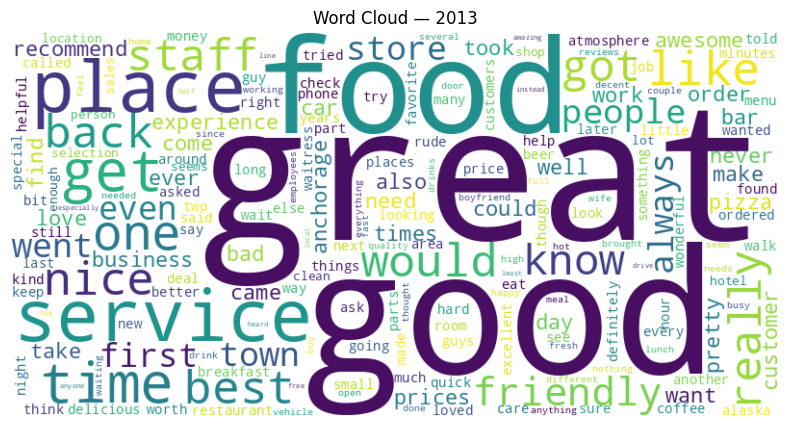

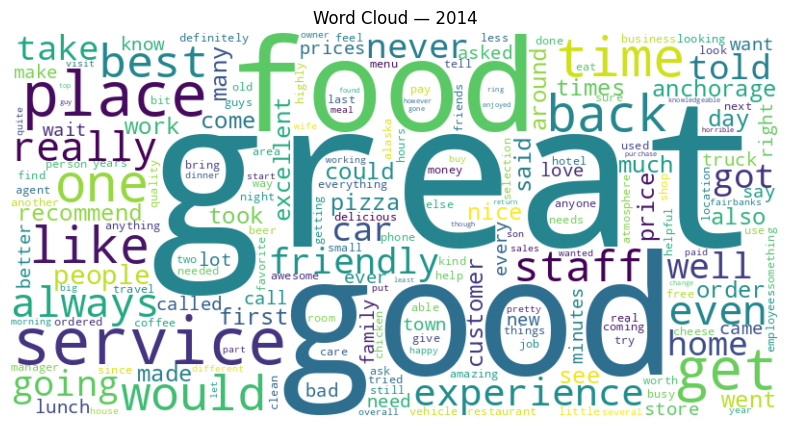

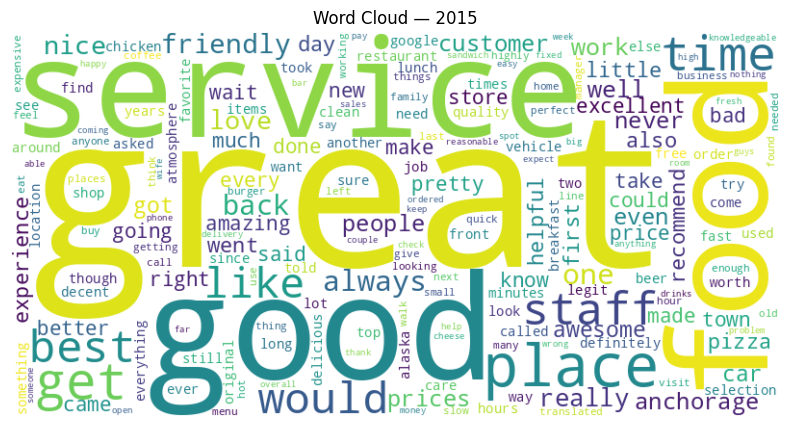

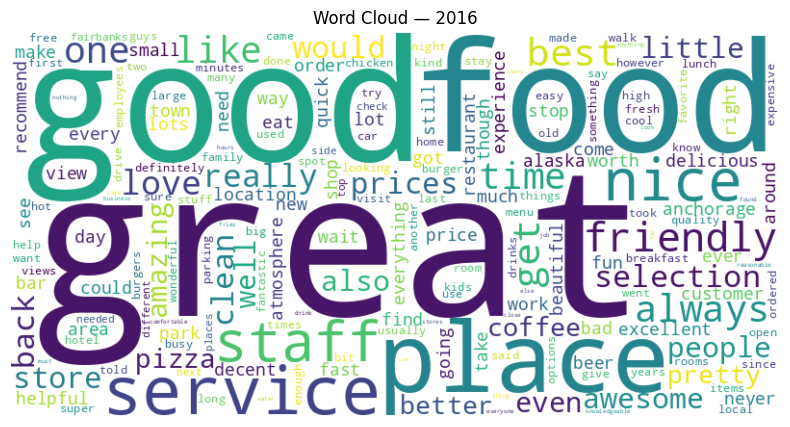

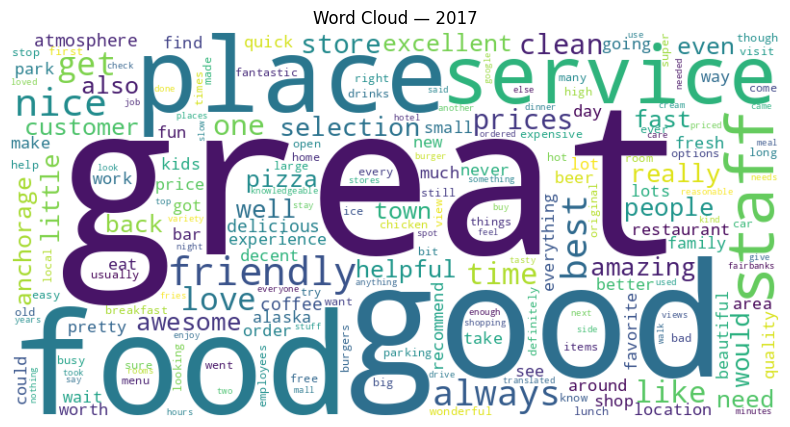

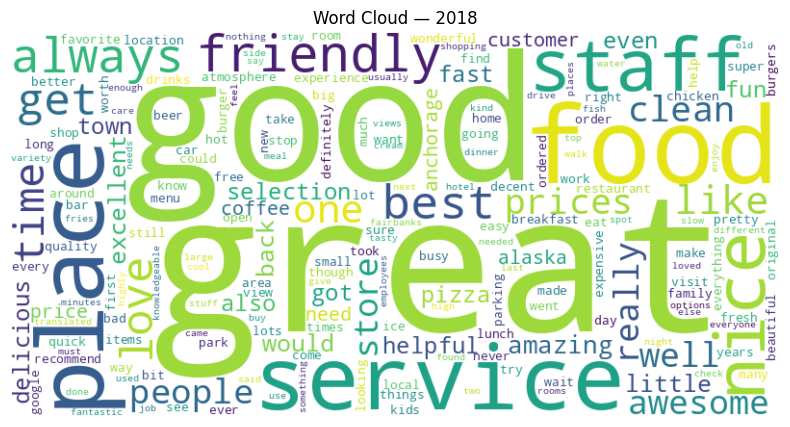

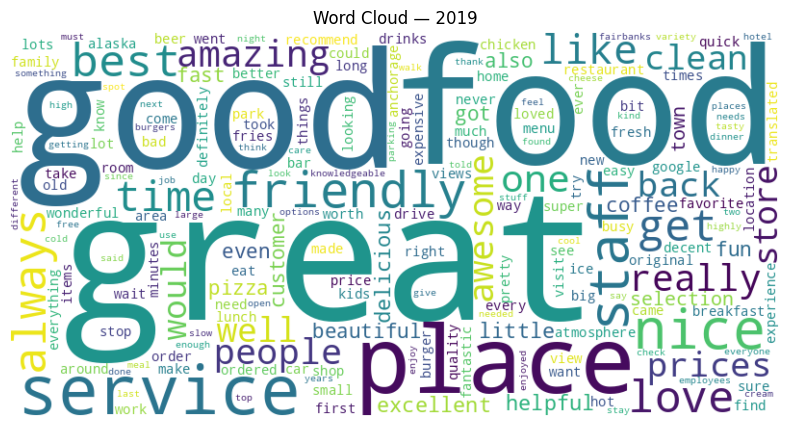

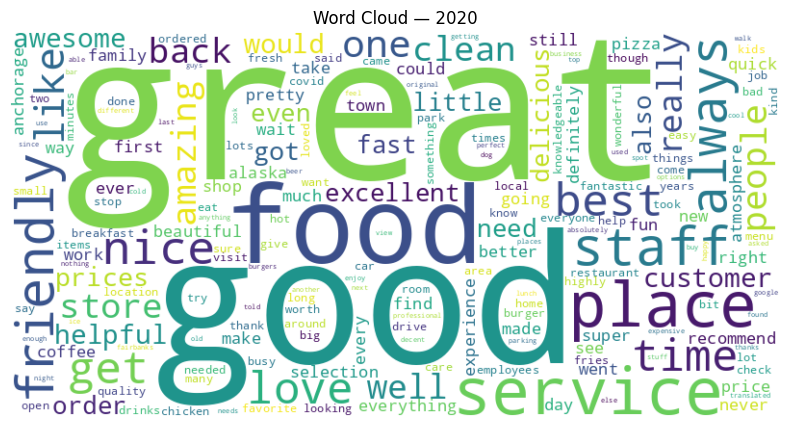

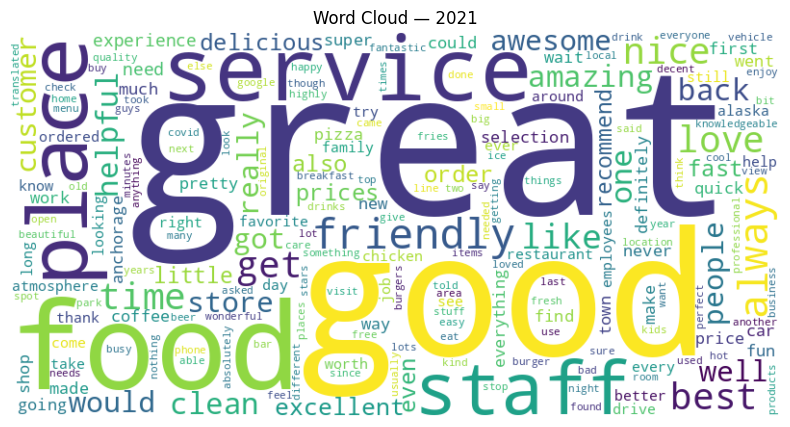

In [32]:
years = sorted(df_text["year"].dropna().unique().tolist())
for y in years:
    toks = []
    for t in df_text.loc[df_text["year"]==y, col_text]: toks.extend(tokenize(t))
    freq = Counter(toks)
    if not freq: continue
    wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(freq)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud — {y}")
    plt.show()


Q1.5

In [33]:
distinct_by_business = joined_sdf.groupBy(name_col).agg(F.countDistinct(col_user).alias("uniq_reviewers")).orderBy(F.desc("uniq_reviewers")).limit(15).toPandas()
distinct_by_category = joined_sdf.groupBy(cat_col).agg(F.countDistinct(col_user).alias("uniq_reviewers")).orderBy(F.desc("uniq_reviewers")).limit(15).toPandas()
distinct_by_business, distinct_by_category


(                          business_name  uniq_reviewers
 0                   Walmart Supercenter            7092
 1                            McDonald's            6951
 2                      Costco Wholesale            4430
 3                                 Carrs            4424
 4                             Taco Bell            4402
 5                            Fred Meyer            3664
 6                               Wendy's            3218
 7                               Safeway            2855
 8          Moose's Tooth Pub & Pizzeria            2833
 9                                Subway            2782
 10                        Dimond Center            2542
 11              Lowe's Home Improvement            2424
 12            Anchorage 5th Avenue Mall            2116
 13  Red Robin Gourmet Burgers and Brews            2025
 14                      Texas Roadhouse            2021,
                                              category  uniq_reviewers
 0              

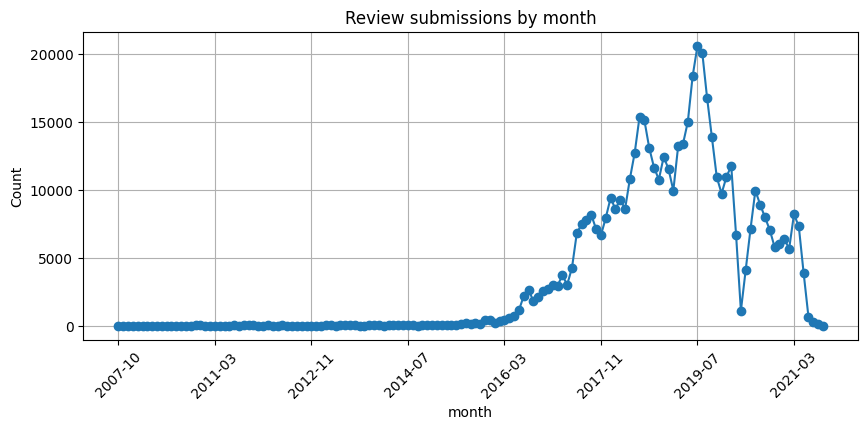

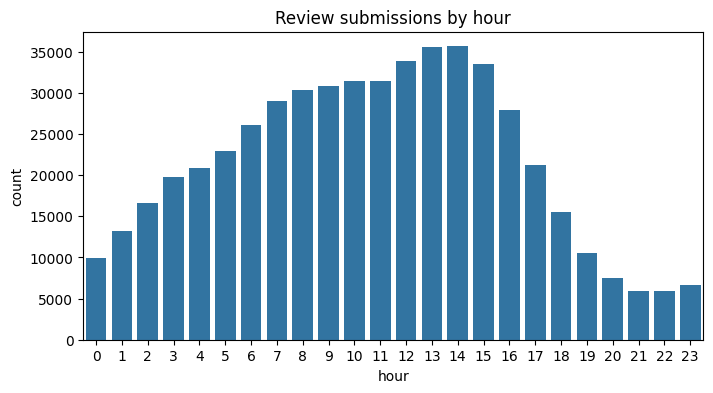

In [35]:
pdf = joined_sdf.select(col_user, name_col, cat_col, col_rating, "newtime", "timestamp_parsed").toPandas()
pdf["date"] = pd.to_datetime(pdf["newtime"])
pdf["month"] = pdf["date"].dt.to_period("M").astype(str)
pdf["hour"]  = pd.to_datetime(pdf["timestamp_parsed"]).dt.hour.fillna(0).astype(int)

plt.figure(figsize=(10,4))
pdf.groupby("month").size().plot(marker="o")
plt.xticks(rotation=45)
plt.title("Review submissions by month")
plt.ylabel("Count")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(x="hour", data=pdf, order=sorted(pdf["hour"].unique()))
plt.title("Review submissions by hour")
plt.show()

Q1.6

In [36]:


use_pdf = joined_sdf.select(col_user, name_col, col_rating).dropna().toPandas()
use_pdf[col_rating] = pd.to_numeric(use_pdf[col_rating], errors="coerce")
use_pdf = use_pdf.dropna()

user_ids = use_pdf[col_user].astype(str).astype("category")
item_ids = use_pdf[name_col].astype(str).astype("category")

row = user_ids.cat.codes.values
col = item_ids.cat.codes.values
data = use_pdf[col_rating].values
mat = csr_matrix((data, (row, col)), shape=(user_ids.cat.categories.size, item_ids.cat.categories.size))

knn = NearestNeighbors(metric="cosine", algorithm="brute", n_neighbors=11)
knn.fit(mat.T)
inv_item_index = dict(enumerate(item_ids.cat.categories))

def similar_items(item_name, k=10):
    if item_name not in item_ids.cat.categories: return []
    idx = list(item_ids.cat.categories).index(item_name)
    dists, idxs = knn.kneighbors(mat.T[idx], n_neighbors=min(k+1, mat.T.shape[0]))
    return [(inv_item_index[j], float(1 - d)) for d, j in zip(dists.flatten(), idxs.flatten()) if j != idx]

def recommend_for_user(user_value, topn=10):
    if str(user_value) not in user_ids.cat.categories: return []
    uidx = list(user_ids.cat.categories).index(str(user_value))
    user_vector = mat[uidx]
    owned = set(np.where(user_vector.toarray().flatten() > 0)[0])
    scores = {}
    for i in owned:
        for n_name, sim in similar_items(inv_item_index[i], k=50):
            j = list(item_ids.cat.categories).index(n_name)
            if j in owned: continue
            scores[j] = scores.get(j, 0.0) + sim
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:topn]
    return [(inv_item_index[j], s) for j, s in ranked]

user_hist = use_pdf[col_user].value_counts()
sample_user = user_hist[user_hist >= 3].index[0] if (user_hist >= 3).any() else user_hist.index[0]
recs = recommend_for_user(sample_user, topn=10)
print("User:", sample_user)
for name, score in recs:
    print(f"{name} | score={score:.3f}")


User: 1.0188830200557922e+20
Texas Roadhouse | score=12.811
Century 16 and XD | score=11.040
Village Inn | score=10.723
Alaska Laser Wash | score=10.407
AutoZone Auto Parts | score=7.696
Cabela's | score=7.440
Golden Corral Buffet & Grill | score=7.098
New Sagaya Midtown Market | score=6.160
Safeway | score=6.049
Windbreak Hotel, Cafe & Lounge | score=5.207


Q1.7

/tmp/ipykernel_71789/2811430345.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


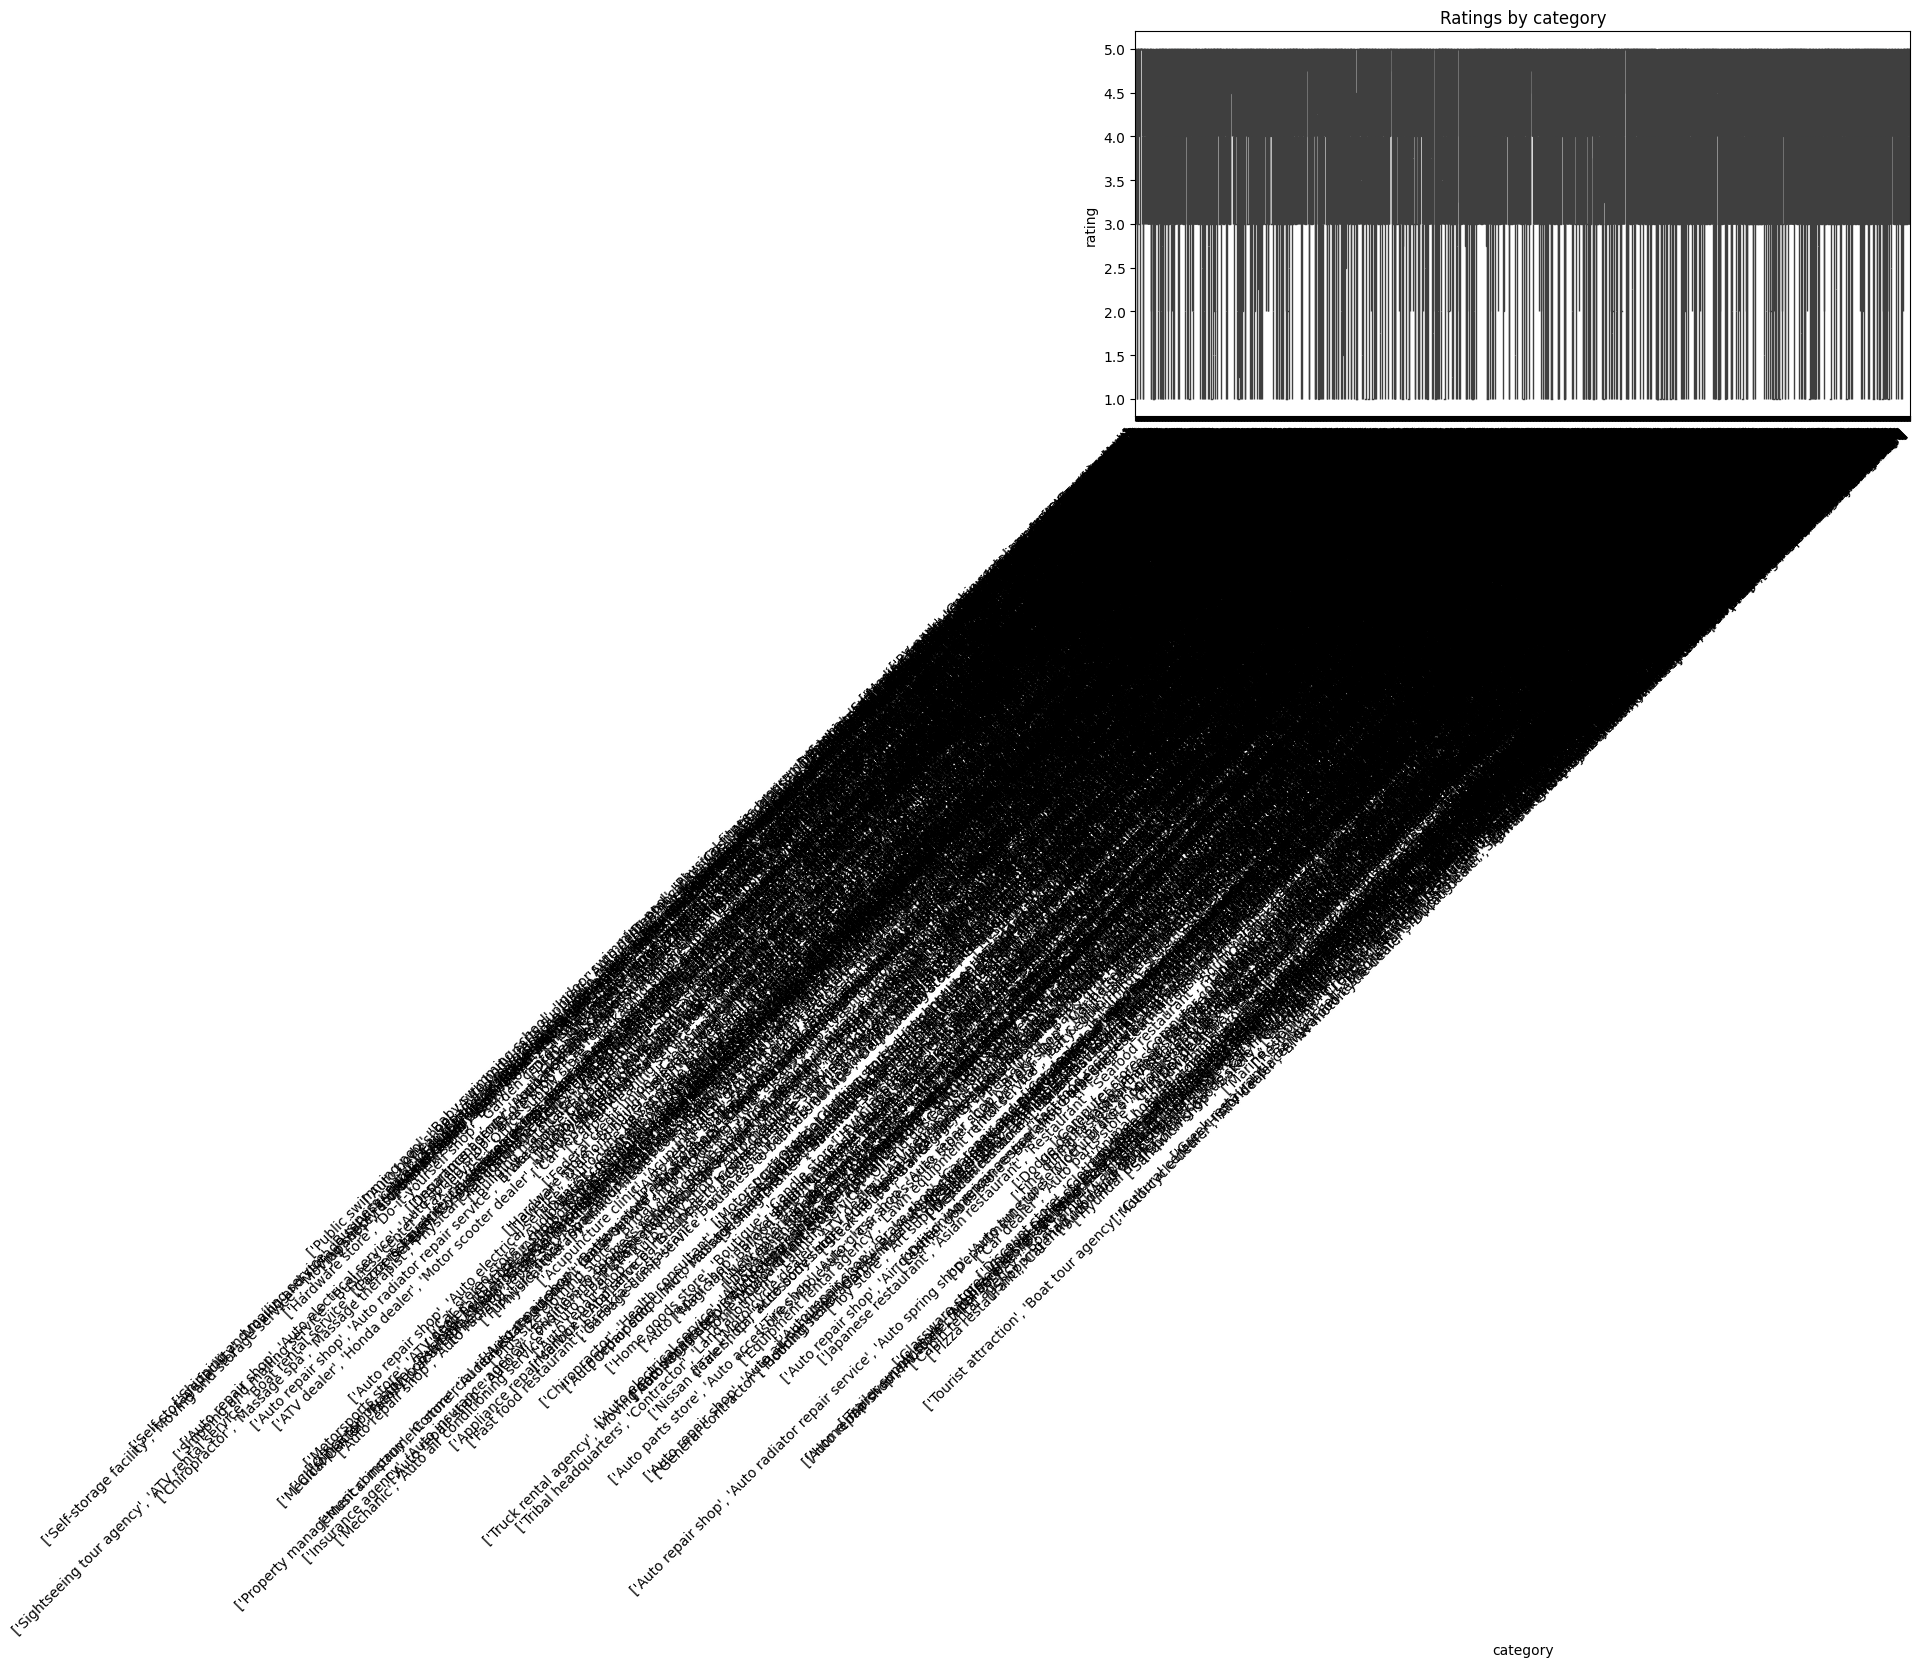

In [37]:
cat_rating_pdf = joined_sdf.select(cat_col, col_rating).dropna().toPandas()
cat_rating_pdf[col_rating] = pd.to_numeric(cat_rating_pdf[col_rating], errors="coerce")
cat_rating_pdf = cat_rating_pdf.dropna()

plt.figure(figsize=(10,5))
sns.boxplot(data=cat_rating_pdf, x=cat_col, y=col_rating, showfliers=False)
plt.xticks(rotation=45, ha="right")
plt.title("Ratings by category")
plt.tight_layout()
plt.show()


In [38]:
low_pdf = joined_sdf.select(col_text, col_rating).toPandas()
low_pdf[col_rating] = pd.to_numeric(low_pdf[col_rating], errors="coerce")
low_pdf = low_pdf.dropna()
low_pdf = low_pdf[low_pdf[col_rating] <= 2]

from collections import Counter
low_tokens = []
for t in low_pdf[col_text]: low_tokens.extend(tokenize(t))
Counter(low_tokens).most_common(40)[:30]


[('food', 6453),
 ('service', 5249),
 ('get', 4284),
 ('time', 3737),
 ('like', 3500),
 ('place', 3495),
 ('good', 3259),
 ('one', 3247),
 ('back', 3096),
 ('would', 3055),
 ('never', 2633),
 ('even', 2590),
 ('order', 2541),
 ('got', 2408),
 ('customer', 2092),
 ('people', 2056),
 ('told', 1944),
 ('said', 1932),
 ('went', 1770),
 ('staff', 1766),
 ('minutes', 1751),
 ('bad', 1650),
 ('could', 1620),
 ('store', 1606),
 ('going', 1576),
 ('ordered', 1531),
 ('way', 1501),
 ('rude', 1495),
 ('asked', 1451),
 ('really', 1412)]

Q1.8

In [39]:
seq_pdf = joined_sdf.select(col_user, name_col, "newtime").dropna().toPandas()
seq_pdf["date"] = pd.to_datetime(seq_pdf["newtime"])
seq_pdf = seq_pdf.sort_values([col_user, "date"])
user_business_list_before = seq_pdf.groupby(col_user)[name_col].apply(list).to_dict()


In [40]:
def dedup_preserve_order(lst):
    seen, out = set(), []
    for x in lst:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out

user_business_list_after = {u: dedup_preserve_order(lst) for u, lst in user_business_list_before.items()}
sizes_before = {u: len(lst) for u, lst in user_business_list_before.items()}
sizes_after  = {u: len(lst) for u, lst in user_business_list_after.items()}

users_sorted = sorted(user_business_list_before.keys())[:10]
print("Before:", [(u, sizes_before[u]) for u in users_sorted])
print("After:",  [(u, sizes_after[u])  for u in users_sorted])


Before: [(1.0000266958784963e+20, 23), (1.00003825755859e+20, 17), (1.0000428139011082e+20, 10), (1.0000609083371541e+20, 48), (1.0000620838495144e+20, 21), (1.0000670037562006e+20, 17), (1.0000684986283477e+20, 10), (1.000069682173995e+20, 19), (1.0000719467235166e+20, 15), (1.0000787767883584e+20, 21)]
After: [(1.0000266958784963e+20, 21), (1.00003825755859e+20, 16), (1.0000428139011082e+20, 10), (1.0000609083371541e+20, 46), (1.0000620838495144e+20, 20), (1.0000670037562006e+20, 17), (1.0000684986283477e+20, 10), (1.000069682173995e+20, 19), (1.0000719467235166e+20, 14), (1.0000787767883584e+20, 20)]


In [41]:
def jaccard(a, b):
    A, B = set(a), set(b)
    if not A and not B: return 0.0
    return len(A & B) / len(A | B)

users = list(user_business_list_after.keys())[:500]
pairs = []
for i in range(len(users)):
    for j in range(i+1, len(users)):
        u, v = users[i], users[j]
        s = jaccard(user_business_list_after[u], user_business_list_after[v])
        if s > 0: pairs.append((u, v, s))
sorted(pairs, key=lambda x: x[2], reverse=True)[:20]


[(1.0040405110904088e+20, 1.0041073966695685e+20, 0.3),
 (1.0041648727849982e+20, 1.004250172563465e+20, 0.2857142857142857),
 (1.000551996007542e+20, 1.001280661069379e+20, 0.2777777777777778),
 (1.00037542907993e+20, 1.0004419405556204e+20, 0.2564102564102564),
 (1.0004419405556204e+20, 1.0024464146828398e+20, 0.25),
 (1.0038657926564048e+20, 1.0042968613982839e+20, 0.25),
 (1.0012710545068709e+20, 1.0036335170537221e+20, 0.23809523809523808),
 (1.0016541678700125e+20, 1.0018793926247147e+20, 0.23809523809523808),
 (1.0001363442299698e+20, 1.0022552595204933e+20, 0.23529411764705882),
 (1.0018707274884989e+20, 1.0041073966695685e+20, 0.23529411764705882),
 (1.0023716729966544e+20, 1.0045216821525753e+20, 0.23529411764705882),
 (1.000371641951149e+20, 1.0036913415979739e+20, 0.23076923076923078),
 (1.0004419405556204e+20, 1.0023716729966544e+20, 0.23076923076923078),
 (1.0015846420067562e+20, 1.0016897049218885e+20, 0.23076923076923078),
 (1.003545639298187e+20, 1.004219681043293e+20,

Part 2

Q2.1

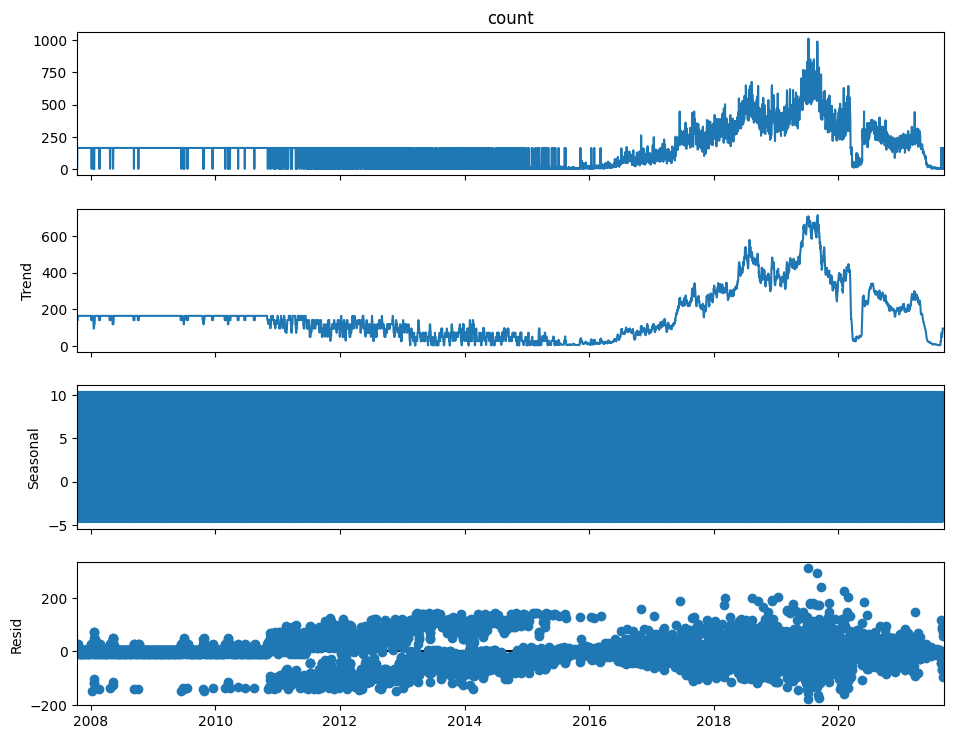

In [42]:
ts_pdf = reviews_sdf.select("newtime").dropna().toPandas()
ts_pdf["date"] = pd.to_datetime(ts_pdf["newtime"])
daily = ts_pdf.groupby("date").size().rename("count").to_frame()
full_range = pd.date_range(daily.index.min(), daily.index.max(), freq="D")
daily = daily.reindex(full_range)
global_mean = daily["count"].mean()
daily["count"] = daily["count"].fillna(global_mean)

from statsmodels.tsa.seasonal import seasonal_decompose
res = seasonal_decompose(daily["count"], model="additive", period=7)
fig = res.plot()
fig.set_size_inches(10, 8)
plt.show()


Q2.2

/home/josh/code/SIT742 - Modern Data Science/venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/josh/code/SIT742 - Modern Data Science/venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/josh/code/SIT742 - Modern Data Science/venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/josh/code/SIT742 - Modern Data Science/venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zero

Best ARIMA(p,d,q) by MAE: (1, 0, 2) MAE: 126.10219482753922


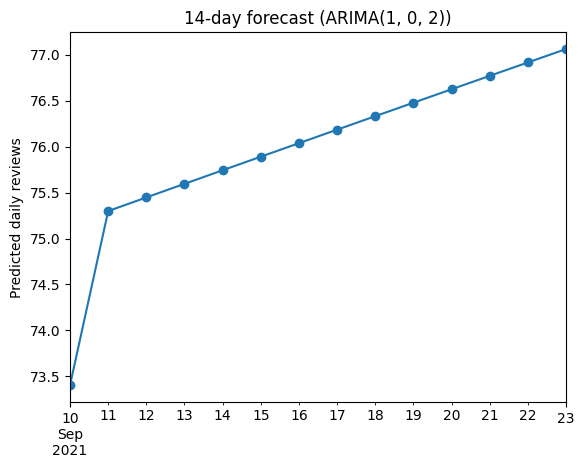

In [43]:


y = daily["count"].astype(float)
split = int(len(y)*0.8)
train, test = y.iloc[:split], y.iloc[split:]

best, best_mae = None, np.inf
for p,d,q in itertools.product([0,1,2],[0,1,2],[0,1,2]):
    try:
        fit = ARIMA(train, order=(p,d,q)).fit(method_kwargs={"warn_convergence": False})
        mae = mean_absolute_error(test, fit.forecast(steps=len(test)))
        if mae < best_mae:
            best_mae, best = mae, (p,d,q)
    except Exception:
        continue

print("Best ARIMA(p,d,q) by MAE:", best, "MAE:", best_mae)
if best:
    fit = ARIMA(y, order=best).fit(method_kwargs={"warn_convergence": False})
    fc = fit.forecast(steps=14)
    fc.plot(marker="o", title=f"14-day forecast (ARIMA{best})")
    plt.ylabel("Predicted daily reviews")
    plt.show()


Q2.3 - Missing Data Analysis with MissMecha-py

In [9]:
# Q2.3 - Missing Data Analysis using MissMecha-py
# MissMecha-py is a comprehensive library for missing data analysis and visualization

print("=== Setting up Missing Data Analysis ===")
print("MissMecha-py provides advanced tools for:")
print("• Missing data visualization (heatmaps, bar charts, matrices)")
print("• Missing data pattern analysis")
print("• Correlation analysis between missing values")
print("• Statistical summaries of missingness")

# Check available data for analysis
print(f"\nAvailable datasets:")
print(f"• Reviews data: {reviews_sdf.count():,} records")
if 'meta_sdf' in locals():
    print(f"• Business metadata: {meta_sdf.count():,} records")
print(f"• Column count in reviews: {len(reviews_sdf.columns)}")

# Preview the data structure for missing value analysis
print(f"\nData structure preview:")
sample_data = reviews_sdf.select(col_user, col_gmap, col_rating, col_text, "newtime", "timestamp_parsed").limit(5).toPandas()
print(sample_data.info())

print("\n" + "="*50)
print("Ready for comprehensive missing data analysis...")
print("="*50)

=== Setting up Missing Data Analysis ===
MissMecha-py provides advanced tools for:
• Missing data visualization (heatmaps, bar charts, matrices)
• Missing data pattern analysis
• Correlation analysis between missing values
• Statistical summaries of missingness

Available datasets:
• Reviews data: 521,515 records
• Reviews data: 521,515 records
• Business metadata: 12,774 records
• Column count in reviews: 10

Data structure preview:
• Business metadata: 12,774 records
• Column count in reviews: 10

Data structure preview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5 non-null      float64       
 1   gmap_id           5 non-null      object        
 2   rating            5 non-null      int32         
 3   text              5 non-null      object        
 4   newtime           5 non-null      object  

=== Missing Data Analysis using MissMecha-py ===
✓ Successfully merged with business metadata

Dataset shape: (4985, 10)
Columns: ['user_id', 'gmap_id', 'rating', 'text', 'newtime', 'timestamp_parsed', 'business_name', 'category', 'avg_rating', 'num_of_reviews']

=== 1. Missing Data Overview ===
             Column  Missing_Count  Missing_Percentage
7          category              1             0.02006
0           user_id              0             0.00000
1           gmap_id              0             0.00000
2            rating              0             0.00000
4           newtime              0             0.00000
3              text              0             0.00000
5  timestamp_parsed              0             0.00000
6     business_name              0             0.00000
8        avg_rating              0             0.00000
9    num_of_reviews              0             0.00000

=== 2. MissMecha Missing Data Matrix ===
Binary Missing Data Matrix:
✓ Successfully merged with b

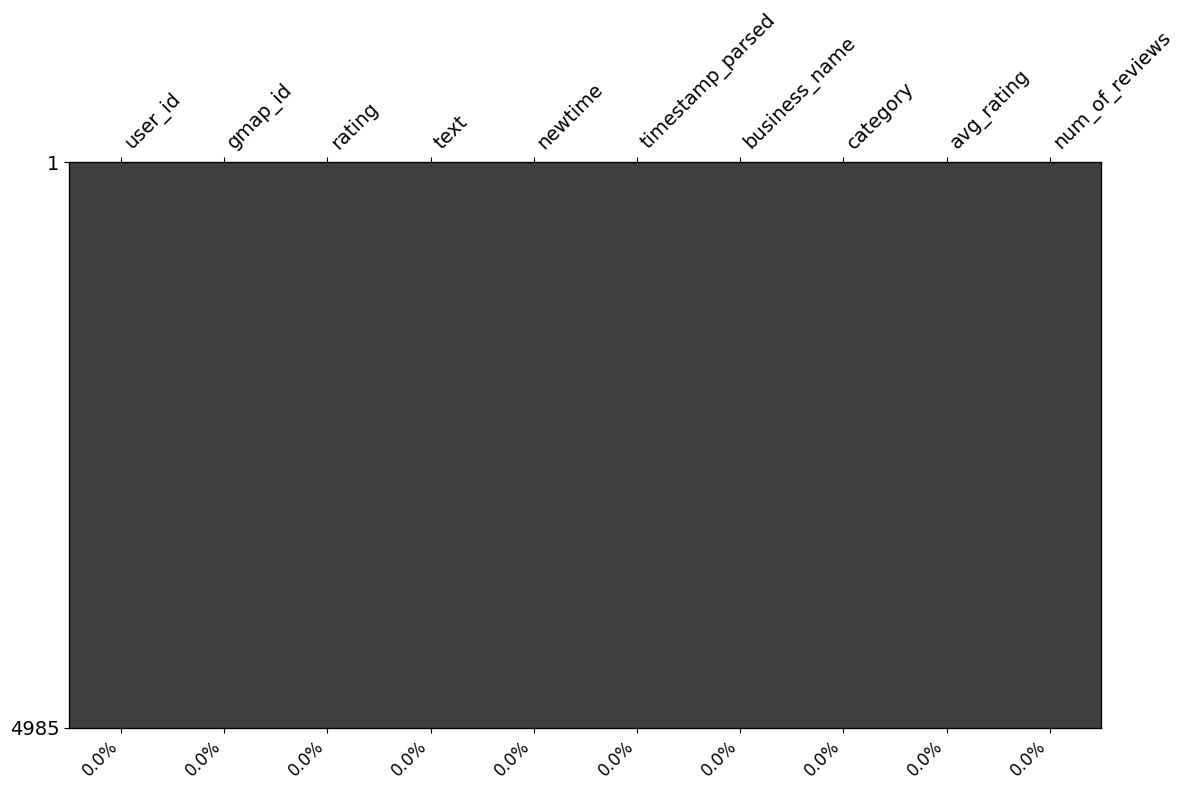

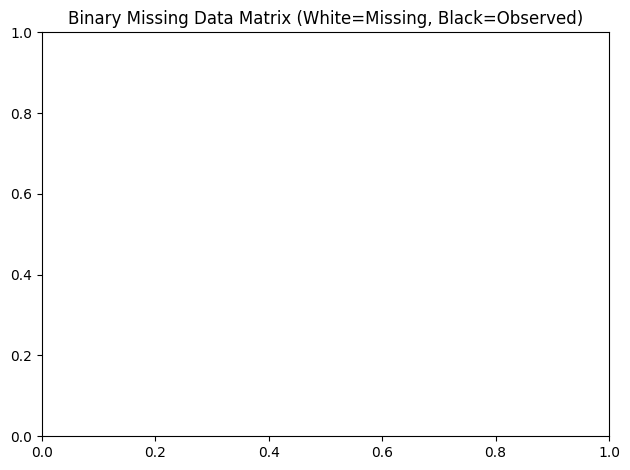


Value-Colored Missing Data Matrix:


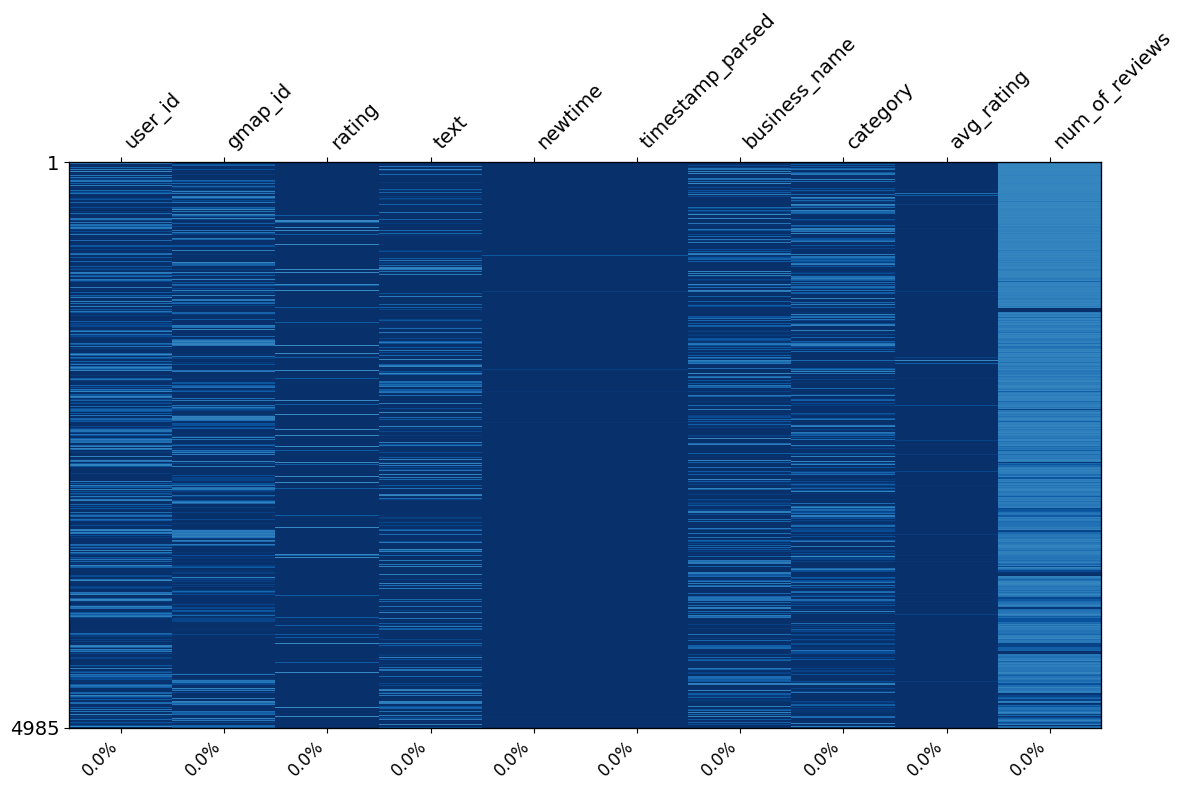

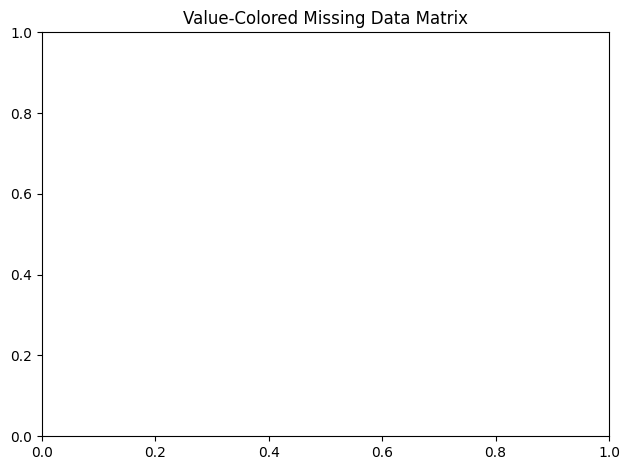


=== 3. MissMecha Nullity Correlation Analysis ===
MissMecha heatmap error: No missing values found in the dataset.


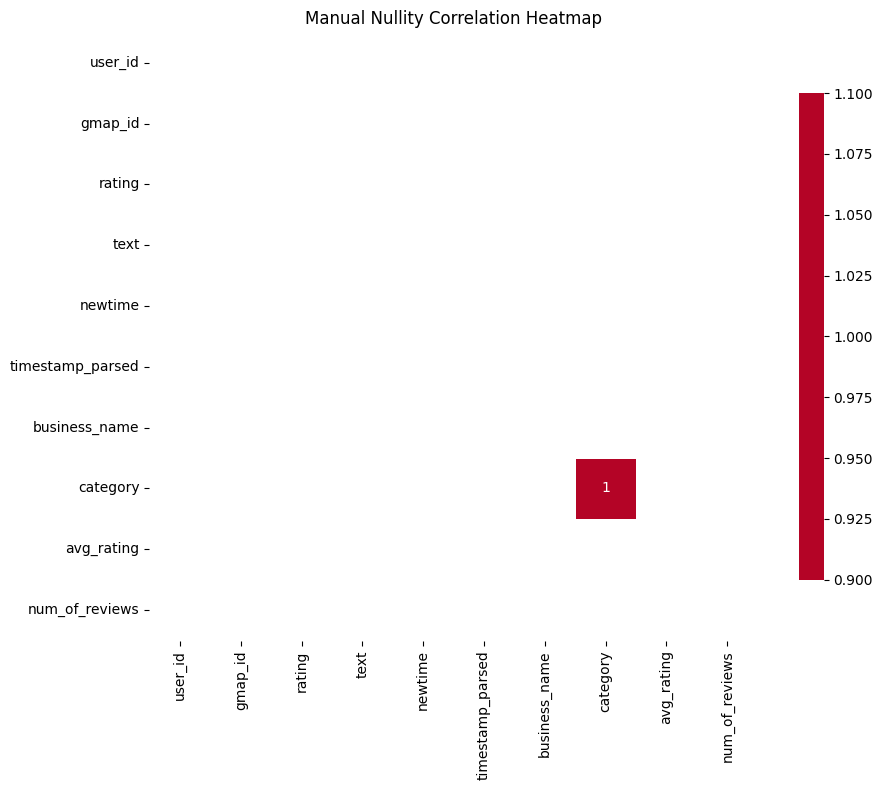


=== 4. Missing Data Patterns ===
Top 10 missing data patterns (1=missing, 0=present):
Pattern 0000000000: 4,984 records (99.98%)
Pattern 0000000100: 1 records (0.02%)

=== 5. MissMecha Generator Demo ===
Demo: Generated missing data using MissMecha:
Original data shape: (100, 2)
Generated missing data - Missing values: 32
Top 10 missing data patterns (1=missing, 0=present):
Pattern 0000000000: 4,984 records (99.98%)
Pattern 0000000100: 1 records (0.02%)

=== 5. MissMecha Generator Demo ===
Demo: Generated missing data using MissMecha:
Original data shape: (100, 2)
Generated missing data - Missing values: 32


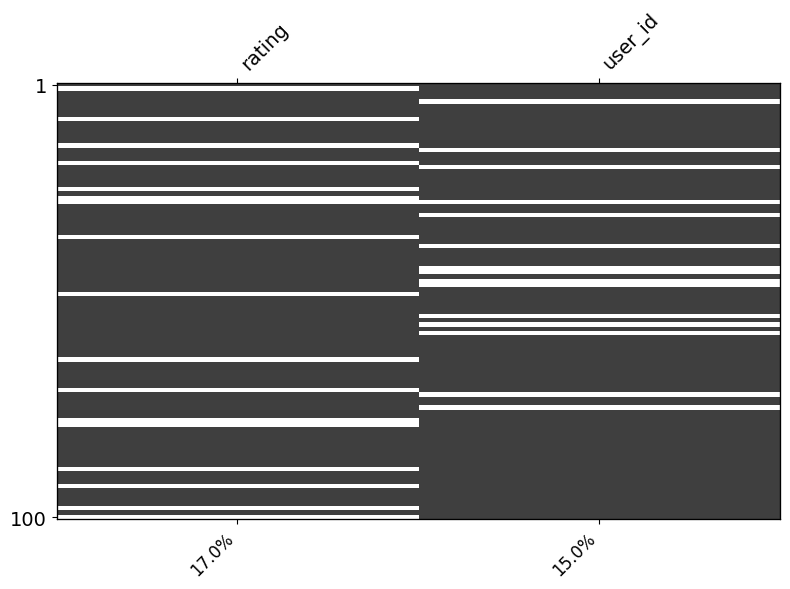

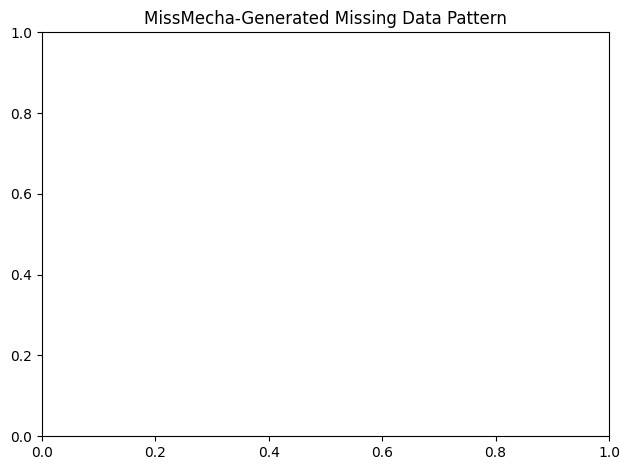


=== 6. Key Insights ===
• Total missing values: 1 out of 49,850 cells (0.00%)
• Columns with missing data: 1 out of 10
• Rows with any missing data: 1 out of 4,985

• No columns have >1% missing data - dataset is very complete!

• Complete rows (no missing values): 4,984 (100.0%)

🎯 Overall Data Quality: Excellent
   Using MissMecha-py for comprehensive missing data analysis
   (Based on 0.00% overall missingness)


In [12]:
# Import MissMecha with correct API
from missmecha.visual import plot_missing_matrix, plot_missing_heatmap
from missmecha.generator import MissMechaGenerator

# Use the reviews dataset for missing data analysis
print("=== Missing Data Analysis using MissMecha-py ===")

# Convert Spark DataFrame to Pandas for MissMecha analysis - sample for performance
sample_size = 5000  # Use a manageable sample size
analysis_df = reviews_sdf.select(col_user, col_gmap, col_rating, col_text, "newtime", "timestamp_parsed").sample(fraction=sample_size/reviews_sdf.count(), seed=42).toPandas()

# Add some business metadata if available
try:
    meta_df = meta_sdf.select("gmap_id", "business_name", "category", "avg_rating", "num_of_reviews").toPandas()
    analysis_df = analysis_df.merge(meta_df, left_on=col_gmap, right_on="gmap_id", how="left")
    # Drop duplicate gmap_id column
    analysis_df = analysis_df.drop('gmap_id_y', axis=1, errors='ignore')
    analysis_df = analysis_df.rename(columns={'gmap_id_x': 'gmap_id'}, errors='ignore')
    print(f"✓ Successfully merged with business metadata")
except Exception as e:
    print(f"→ Using reviews data only: {e}")

print(f"\nDataset shape: {analysis_df.shape}")
print(f"Columns: {list(analysis_df.columns)}")

# 1. Basic Missing Data Overview
print("\n=== 1. Missing Data Overview ===")
missing_counts = analysis_df.isnull().sum()
missing_percentages = (missing_counts / len(analysis_df)) * 100
missing_summary = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing_Count': missing_counts.values,
    'Missing_Percentage': missing_percentages.values
}).sort_values('Missing_Percentage', ascending=False)
print(missing_summary)

# 2. MissMecha Missing Data Matrix Visualization
print("\n=== 2. MissMecha Missing Data Matrix ===")
try:
    # Binary missingness matrix
    print("Binary Missing Data Matrix:")
    plot_missing_matrix(analysis_df, color=False, figsize=(12, 8))
    plt.title("Binary Missing Data Matrix (White=Missing, Black=Observed)")
    plt.tight_layout()
    plt.show()
    
    # Value-colored missingness matrix
    print("\nValue-Colored Missing Data Matrix:")
    plot_missing_matrix(analysis_df, color=True, figsize=(12, 8))
    plt.title("Value-Colored Missing Data Matrix")
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"MissMecha matrix plot error: {e}")
    # Fallback to manual heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(analysis_df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
    plt.title("Missing Data Heatmap (Manual Fallback)")
    plt.xlabel("Columns")
    plt.ylabel("Records")
    plt.tight_layout()
    plt.show()

# 3. MissMecha Nullity Correlation Heatmap
print("\n=== 3. MissMecha Nullity Correlation Analysis ===")
try:
    # Use MissMecha's correlation heatmap
    plot_missing_heatmap(analysis_df, method="pearson", figsize=(10, 8))
    plt.title("Nullity Correlation Heatmap (Pearson)")
    plt.tight_layout()
    plt.show()
    
    # Try with Kendall correlation
    plot_missing_heatmap(analysis_df, method="kendall", figsize=(10, 8))
    plt.title("Nullity Correlation Heatmap (Kendall)")
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"MissMecha heatmap error: {e}")
    # Manual correlation analysis
    missing_indicators = analysis_df.isnull().astype(int)
    missing_corr = missing_indicators.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(missing_corr, annot=True, cmap='coolwarm', center=0, 
                square=True, linewidths=0.5, cbar_kws={"shrink": .8})
    plt.title("Manual Nullity Correlation Heatmap")
    plt.tight_layout()
    plt.show()

# 4. Missing data patterns analysis
print("\n=== 4. Missing Data Patterns ===")
# Analyze combinations of missing data
missing_pattern = analysis_df.isnull().apply(lambda x: ''.join(x.astype(int).astype(str)), axis=1)
pattern_counts = missing_pattern.value_counts().head(10)
print("Top 10 missing data patterns (1=missing, 0=present):")
for pattern, count in pattern_counts.items():
    pct = (count / len(analysis_df)) * 100
    print(f"Pattern {pattern}: {count:,} records ({pct:.2f}%)")

# 5. Demonstrate MissMecha Generator (optional - for educational purposes)
print("\n=== 5. MissMecha Generator Demo ===")
try:
    # Create a small demo dataset to show MissMecha's generation capabilities
    demo_data = analysis_df[['rating', 'user_id']].dropna().head(100)
    
    # Initialize MissMecha generator
    mecha = MissMechaGenerator()
    
    # Generate missing data patterns
    demo_missing = mecha.fit_transform(demo_data.values)
    demo_df = pd.DataFrame(demo_missing, columns=demo_data.columns)
    
    print("Demo: Generated missing data using MissMecha:")
    print(f"Original data shape: {demo_data.shape}")
    print(f"Generated missing data - Missing values: {demo_df.isnull().sum().sum()}")
    
    # Visualize the generated missingness
    plot_missing_matrix(demo_df, color=False, figsize=(8, 6))
    plt.title("MissMecha-Generated Missing Data Pattern")
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"MissMecha generator demo error: {e}")

# 6. Summary insights
print("\n=== 6. Key Insights ===")
total_cells = analysis_df.shape[0] * analysis_df.shape[1]
missing_cells = analysis_df.isnull().sum().sum()
missing_percentage = (missing_cells / total_cells) * 100

print(f"• Total missing values: {missing_cells:,} out of {total_cells:,} cells ({missing_percentage:.2f}%)")
print(f"• Columns with missing data: {analysis_df.isnull().any().sum()} out of {analysis_df.shape[1]}")
print(f"• Rows with any missing data: {analysis_df.isnull().any(axis=1).sum():,} out of {analysis_df.shape[0]:,}")

# Find columns with highest missing percentages
high_missing = missing_percentages[missing_percentages > 1].sort_values(ascending=False)
if len(high_missing) > 0:
    print(f"\n• Columns with >1% missing data:")
    for col, pct in high_missing.items():
        print(f"  - {col}: {pct:.1f}% missing")
else:
    print("\n• No columns have >1% missing data - dataset is very complete!")

# Data quality assessment
complete_rows = (~analysis_df.isnull().any(axis=1)).sum()
complete_percentage = (complete_rows / len(analysis_df)) * 100
print(f"\n• Complete rows (no missing values): {complete_rows:,} ({complete_percentage:.1f}%)")

print(f"\n🎯 Overall Data Quality: {'Excellent' if missing_percentage < 5 else 'Good' if missing_percentage < 15 else 'Moderate'}")
print(f"   Using MissMecha-py for comprehensive missing data analysis")
print(f"   (Based on {missing_percentage:.2f}% overall missingness)")